<center><h1>Hall_Matthew_HW2</h1></center>
<br>
<br>

Name: Matthew Hall
<br>
Github Username: matthall9
<br>
USC ID: 6347959203

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline
sns.set_theme(style="whitegrid")

Get the Cycle Power Plant Data Set

In [2]:
data = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")

data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")
print("\nColumn names:")
print(data.columns.tolist())

data.info()

Number of rows: 9568
Number of columns: 5

Column names:
['AT', 'V', 'AP', 'RH', 'PE']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


The dataset contains 9,568 rows and 5 columns. Each row represents one hourly observation of the combined-cycle power plant operating at full load. The first four columns are predictor variables: ambient temperature, exhaust vacuum, ambient pressure, and relative humidity. The final column, PE, is the net hourly electrical energy output and serves as the target variable.

#### ii. pairwise scatterplots of all the varianbles

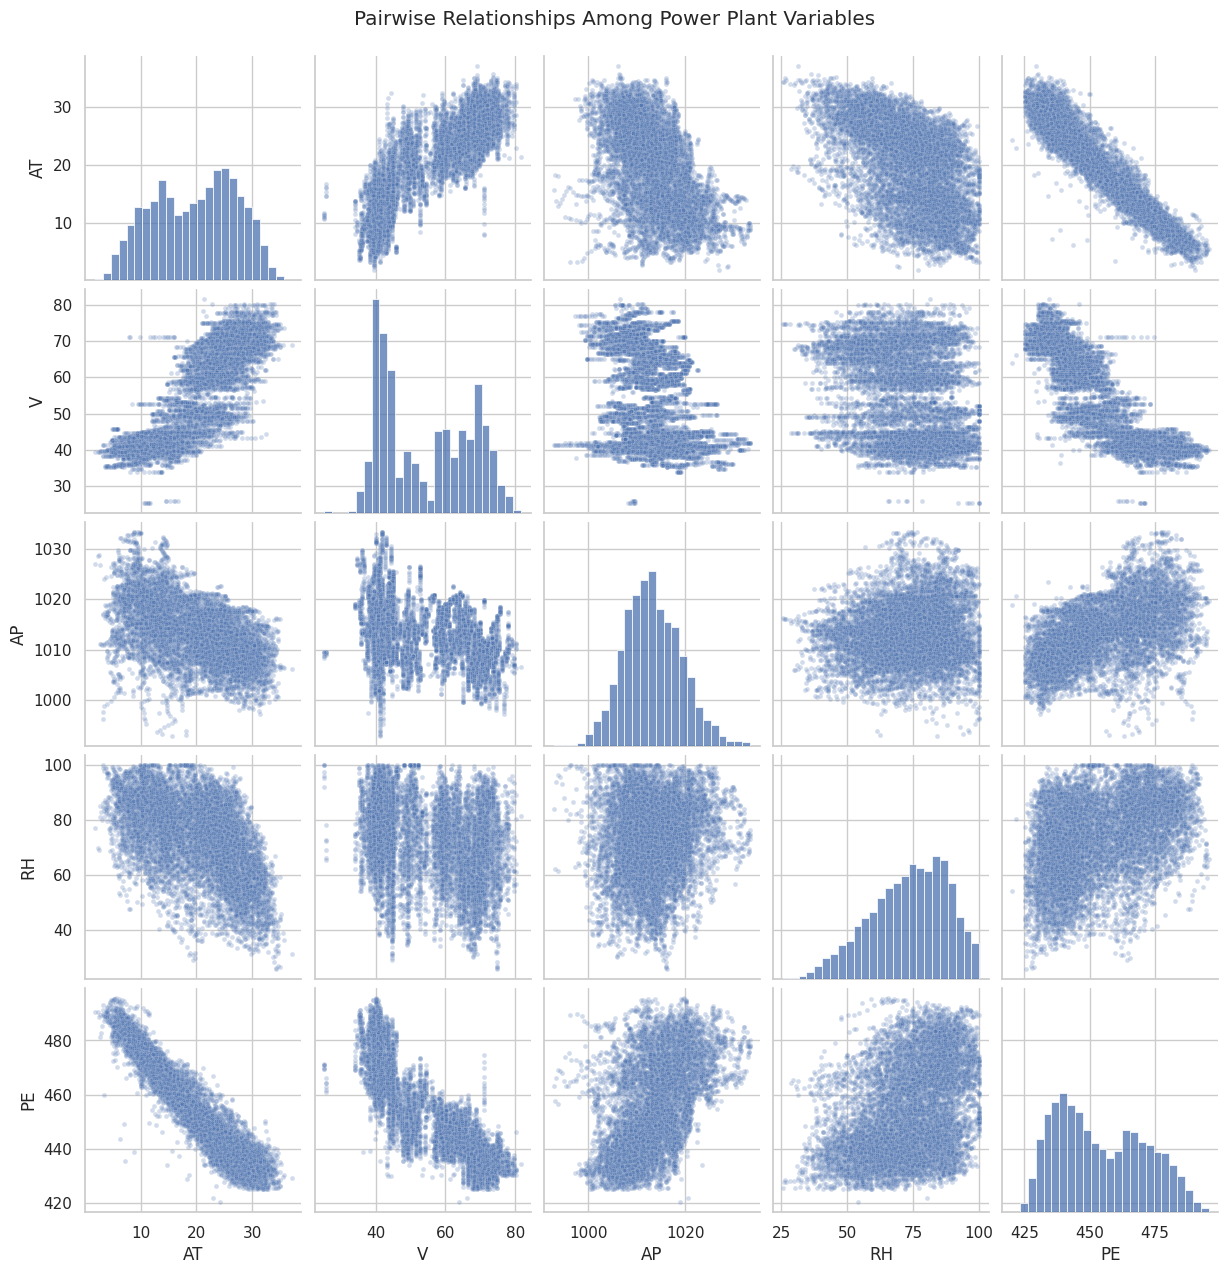

In [4]:
sns.pairplot(
    data,
    diag_kind="hist",
    plot_kws={"alpha": 0.25, "s": 12},
    diag_kws={"bins": 25}
)

plt.suptitle("Pairwise Relationships Among Power Plant Variables", y=1.02)
plt.show()

The clearest pattern in the scatterplots is the strong negative relationship between temperature (`AT`) and electrical output (`PE`). As the temperature rises, the plant generally produces less electricity. Exhaust vacuum (`V`) has a similar negative relationship with output, although it is slightly less pronounced.

Ambient pressure (`AP`) and relative humidity (`RH`) both have positive relationships with output, but these patterns are weaker and more spread out. There are also relationships among the predictors themselves. For example, temperature and exhaust vacuum tend to increase together, while temperature tends to decrease as pressure or humidity increases.

Overall, temperature appears to be the strongest individual predictor of electrical output. Some of the plots also look slightly curved and contain a few unusual points, so nonlinear terms or a closer look at possible outliers may be useful later.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary_stats = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Minimum": data.min(),
    "Maximum": data.max(),
    "Range": data.max() - data.min(),
    "First Quartile (Q1)": data.quantile(0.25),
    "Third Quartile (Q3)": data.quantile(0.75),
    "IQR": data.quantile(0.75) - data.quantile(0.25)
})

summary_stats.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


The means and medians are fairly close for all five variables, so none of their distributions appear to be extremely skewed. Ambient pressure (`AP`) has the smallest interquartile range relative to its overall values, meaning that most pressure measurements are grouped fairly closely together. Electrical output (`PE`) ranges from 420.26 to 495.76 MW, with the middle 50% of observations falling between 439.75 and 468.43 MW.

### (c) Simple Linear Regression

In [6]:
predictors = ["AT", "V", "AP", "RH"]
simple_models = {}
simple_results = []

for predictor in predictors:
    X = sm.add_constant(data[[predictor]])
    y = data["PE"]

    model = sm.OLS(y, X).fit()
    simple_models[predictor] = model

    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_results_df = pd.DataFrame(simple_results)
simple_results_df.round(4)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.0341,-2.1713,0.0,0.8989
1,V,517.8015,-1.1681,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0,0.2688
3,RH,420.9618,0.4557,0.0,0.1519


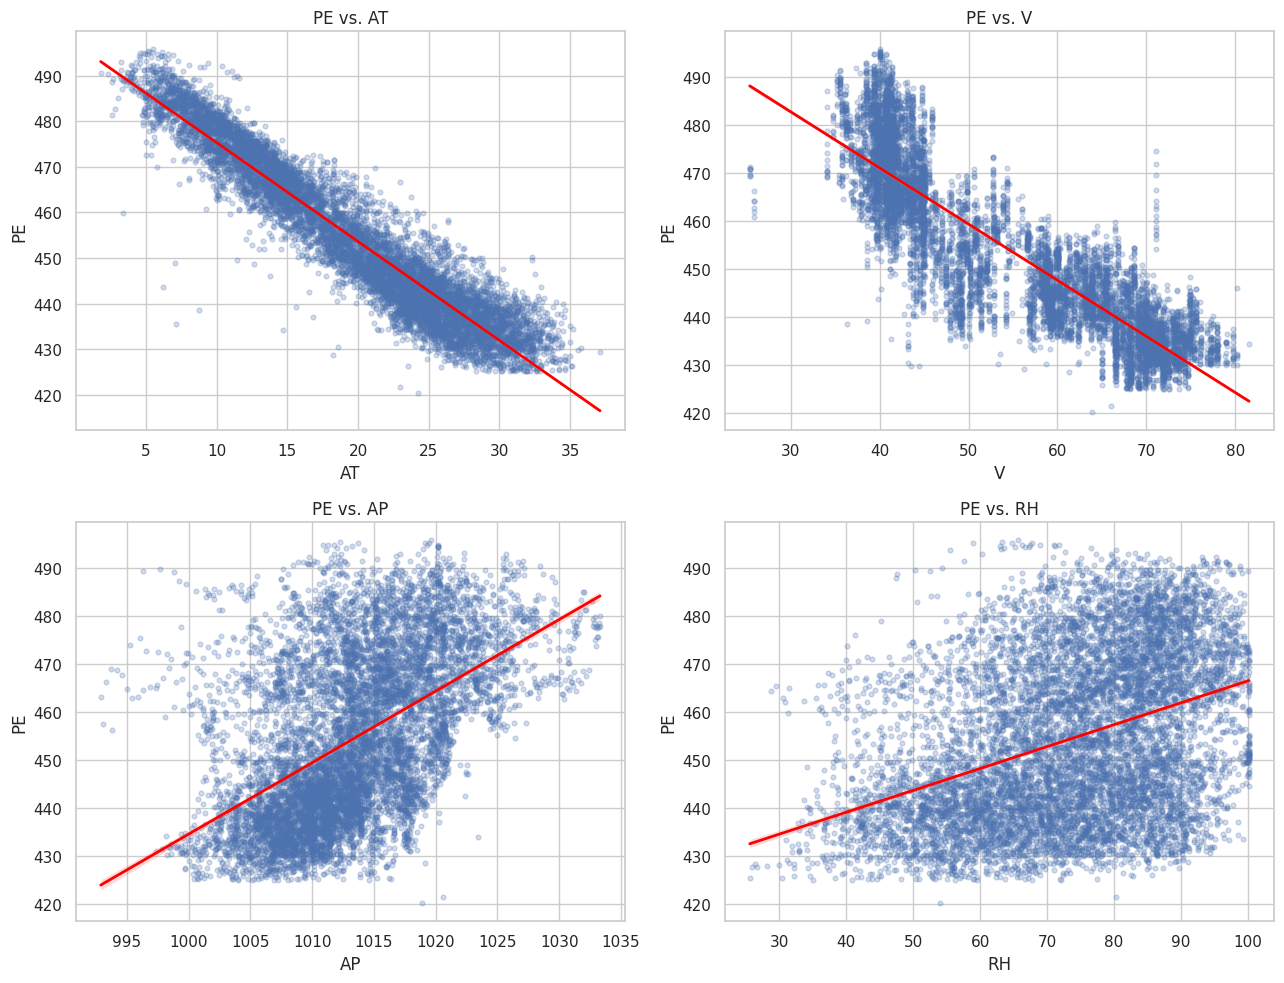

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(
        data=data,
        x=predictor,
        y="PE",
        scatter_kws={"alpha": 0.25, "s": 12},
        line_kws={"color": "red", "linewidth": 2},
        ax=ax
    )

    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

In [8]:
outlier_results = []

for predictor, model in simple_models.items():
    influence = model.get_influence().summary_frame()

    outlier_results.append({
        "Predictor": predictor,
        "|Studentized Residual| > 3": (
            influence["student_resid"].abs() > 3
        ).sum(),
        "Maximum Cook's Distance": influence["cooks_d"].max()
    })

outlier_results_df = pd.DataFrame(outlier_results)
outlier_results_df.round(4)

,Predictor,|Studentized Residual| > 3,Maximum Cook's Distance
0,AT,42,0.0143
1,V,33,0.0032
2,AP,30,0.0082
3,RH,2,0.0021


All four predictors have a statistically significant relationship with electrical output since each p-value is below 0.001. However, the strength of these relationships is very different.

Temperature (`AT`) has the strongest individual relationship with output. Its coefficient is about -2.17, meaning that a one-unit increase in temperature is associated with an average decrease of about 2.17 MW in electrical output. Its R-squared value of 0.899 means that temperature alone explains almost 90% of the variation in output.

Exhaust vacuum (`V`) also has a strong negative relationship with output. A one-unit increase in `V` is associated with an average decrease of about 1.17 MW, and the model explains about 75.7% of the variation in output.

Ambient pressure (`AP`) and relative humidity (`RH`) both have positive coefficients, but their individual models are much weaker. Their R-squared values are about 0.269 and 0.152, respectively.

The plots and studentized residuals show a few unusual observations, especially in the temperature model. However, none of the points has a very large Cook's distance, so no single observation has an extreme effect on the regression line. I would keep these observations unless there is evidence that they resulted from measurement or data-entry errors.

### (d) Multiple Regression

In [9]:
X_multiple = sm.add_constant(data[["AT", "V", "AP", "RH"]])
y = data["PE"]

multiple_model = sm.OLS(y, X_multiple).fit()
multiple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:07:24   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [10]:
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard Error": multiple_model.bse,
    "T-statistic": multiple_model.tvalues,
    "P-value": multiple_model.pvalues
})

multiple_results.round(4)

,Coefficient,Standard Error,T-statistic,P-value
const,454.6093,9.7485,46.6337,0.0
AT,-1.9775,0.0153,-129.3420,0.0
V,-0.2339,0.0073,-32.1221,0.0
AP,0.0621,0.0095,6.5641,0.0
RH,-0.1581,0.0042,-37.9185,0.0


The multiple regression model has an R-squared value of 0.929, meaning that the four predictors together explain about 92.9% of the variation in electrical output. This is better than any of the simple regression models, although temperature alone already explained a large portion of the variation.

All four predictors have p-values below 0.001, so I can reject the null hypothesis \(H_0: \beta_j = 0\) for `AT`, `V`, `AP`, and `RH`.

Holding the other predictors constant, a one-unit increase in temperature (`AT`) is associated with an average decrease of about 1.98 MW in electrical output. A one-unit increase in exhaust vacuum (`V`) is associated with a decrease of about 0.23 MW, while a one-unit increase in ambient pressure (`AP`) is associated with an increase of about 0.06 MW. A one-unit increase in relative humidity (`RH`) is associated with a decrease of about 0.16 MW.

One interesting result is that `RH` had a positive coefficient in its simple regression but has a negative coefficient here. This happens because the multiple regression measures the effect of humidity while holding the other predictors constant. Since humidity is related to variables such as temperature, its coefficient changes once those variables are included in the model.

### (e) 1c Compare to 1d

In [11]:
simple_coefficients = pd.Series({
    predictor: simple_models[predictor].params[predictor]
    for predictor in predictors
})

multiple_coefficients = multiple_model.params[predictors]

coefficient_comparison = pd.DataFrame({
    "Simple Regression": simple_coefficients,
    "Multiple Regression": multiple_coefficients
})

coefficient_comparison.round(4)

,Simple Regression,Multiple Regression
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


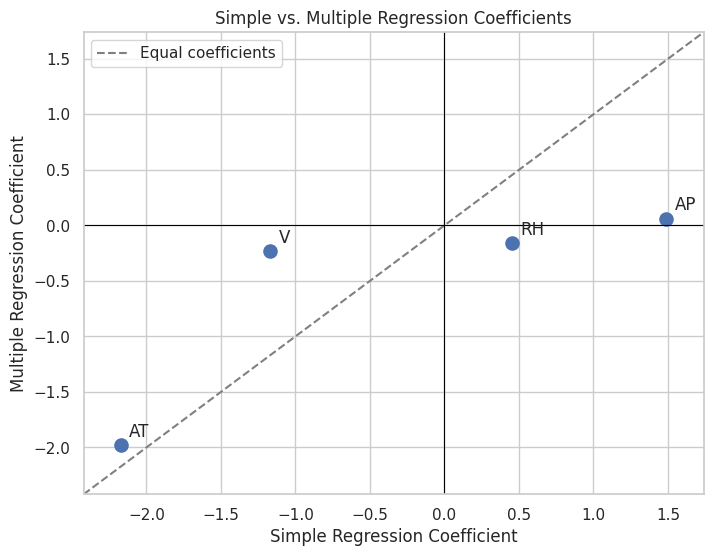

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    s=90
)

for predictor in predictors:
    plt.annotate(
        predictor,
        (
            coefficient_comparison.loc[predictor, "Simple Regression"],
            coefficient_comparison.loc[predictor, "Multiple Regression"]
        ),
        xytext=(6, 6),
        textcoords="offset points"
    )

limits = [
    coefficient_comparison.min().min() - 0.25,
    coefficient_comparison.max().max() + 0.25
]

plt.plot(limits, limits, linestyle="--", color="gray", label="Equal coefficients")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs. Multiple Regression Coefficients")
plt.legend()
plt.show()

The coefficients from the simple and multiple regressions are noticeably different. The temperature coefficient changes the least, remaining strongly negative in both models. The coefficients for exhaust vacuum and ambient pressure become much smaller once the other predictors are included.

The largest directional change occurs for relative humidity. Its coefficient is positive in the simple regression but negative in the multiple regression. This suggests that the simple regression was also picking up the effects of other variables related to humidity, especially temperature. The multiple regression separates these effects by estimating each coefficient while holding the other predictors constant.

### (f) Nonlinear Association

In [13]:
nonlinear_models = {}
nonlinear_results = []

for predictor in predictors:
    x = data[predictor]
    z = (x - x.mean()) / x.std()

    X_poly = pd.DataFrame({
        "X": z,
        "X_squared": z**2,
        "X_cubed": z**3
    })

    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(data["PE"], X_poly).fit()
    nonlinear_models[predictor] = model

    # Jointly test whether the quadratic and cubic terms are both zero
    nonlinear_test = model.f_test("X_squared = 0, X_cubed = 0")

    nonlinear_results.append({
        "Predictor": predictor,
        "Linear P-value": model.pvalues["X"],
        "Quadratic P-value": model.pvalues["X_squared"],
        "Cubic P-value": model.pvalues["X_cubed"],
        "Nonlinear Terms Joint P-value": float(nonlinear_test.pvalue),
        "R-squared": model.rsquared
    })

nonlinear_results_df = pd.DataFrame(nonlinear_results)
nonlinear_results_df.round(6)

,Predictor,Linear P-value,Quadratic P-value,Cubic P-value,Nonlinear Terms Joint P-value,R-squared
0,AT,0.0,0.000000,0.000000,0.000000,0.911883
1,V,0.0,0.000000,0.013735,0.000000,0.775022
2,AP,0.0,0.000000,0.000000,0.000000,0.297543
3,RH,0.0,0.101395,0.000014,0.000038,0.153743


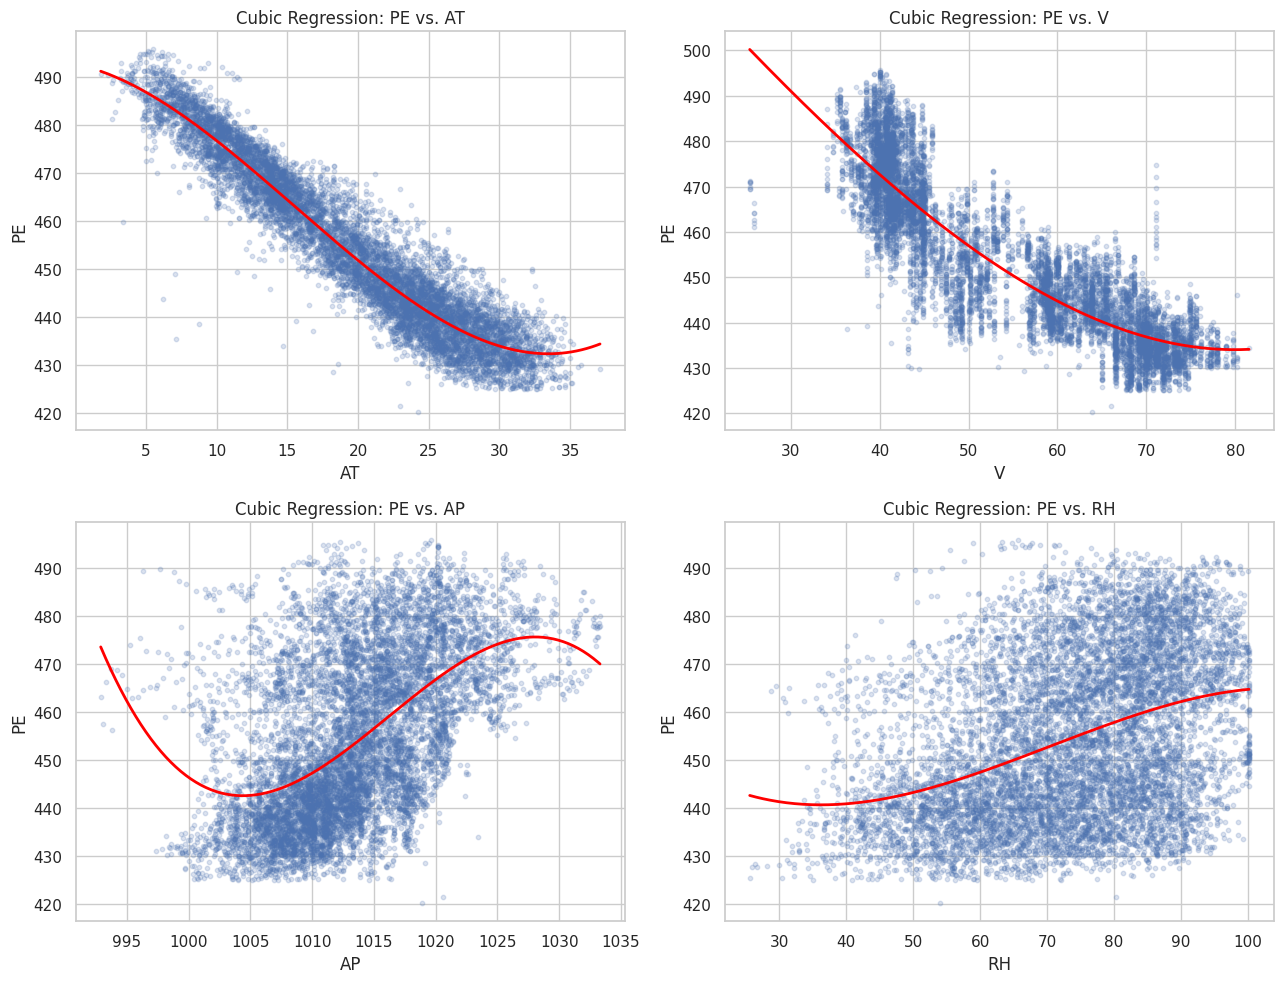

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    x = data[predictor]
    x_grid = np.linspace(x.min(), x.max(), 300)

    mean = x.mean()
    std = x.std()
    z_grid = (x_grid - mean) / std

    X_grid = pd.DataFrame({
        "X": z_grid,
        "X_squared": z_grid**2,
        "X_cubed": z_grid**3
    })

    X_grid = sm.add_constant(X_grid, has_constant="add")
    y_pred = nonlinear_models[predictor].predict(X_grid)

    ax.scatter(x, data["PE"], alpha=0.2, s=10)
    ax.plot(x_grid, y_pred, color="red", linewidth=2)
    ax.set_title(f"Cubic Regression: PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

There is evidence of a nonlinear relationship between each predictor and electrical output. The joint tests for the quadratic and cubic terms have p-values below 0.001 for all four predictors.

For `AT`, `V`, and `AP`, both the quadratic and cubic terms are statistically significant. For `RH`, the quadratic term is not significant by itself, but the cubic term is significant, and the two nonlinear terms are jointly significant.

The improvement in R-squared is most noticeable for `AT`, `V`, and `AP`. The R-squared for `RH` only increases from about 0.152 in the linear model to 0.154 in the cubic model. This means the nonlinear relationship for humidity is statistically detectable because the dataset is large, but it does not improve the model very much in practical terms.

### (g) Interactions of Predictors

In [15]:
import statsmodels.formula.api as smf

interaction_model = smf.ols(
    "PE ~ (AT + V + AP + RH) ** 2",
    data=data
).fit()

interaction_terms = [
    "AT:V", "AT:AP", "AT:RH",
    "V:AP", "V:RH", "AP:RH"
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "P-value": interaction_model.pvalues[interaction_terms]
})

interaction_results.round(6)

,Coefficient,P-value
AT:V,0.020971,0.000000
AT:AP,0.001759,0.452051
AT:RH,-0.005230,0.000000
V:AP,0.006812,0.000000
V:RH,0.000839,0.086194
AP:RH,-0.001612,0.033606


Four pairwise interaction terms are statistically significant at the 0.05 level: `AT:V`, `AT:RH`, `V:AP`, and `AP:RH`. The `AT:AP` and `V:RH` interactions are not significant.

These results suggest that the relationship between a predictor and electrical output can depend on the value of another predictor. For example, the significant `AT:V` interaction means that the effect of temperature on output changes depending on the exhaust vacuum. Since most of the interaction terms are significant, including interactions may improve the model.

### (h) Improvement

In [16]:
X = data[["AT", "V", "AP", "RH"]]
y = data["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 6697
Testing observations: 2871


In [17]:
X_train_linear = sm.add_constant(X_train)
X_test_linear = sm.add_constant(X_test, has_constant="add")

baseline_model = sm.OLS(y_train, X_train_linear).fit()

baseline_train_predictions = baseline_model.predict(X_train_linear)
baseline_test_predictions = baseline_model.predict(X_test_linear)

baseline_train_mse = mean_squared_error(
    y_train,
    baseline_train_predictions
)

baseline_test_mse = mean_squared_error(
    y_test,
    baseline_test_predictions
)

print(f"Baseline training MSE: {baseline_train_mse:.4f}")
print(f"Baseline test MSE: {baseline_test_mse:.4f}")

Baseline training MSE: 20.5808
Baseline test MSE: 21.2399


In [18]:
poly_scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    poly_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    poly_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = pd.DataFrame(
    poly.fit_transform(X_train_scaled),
    columns=poly.get_feature_names_out(X_train.columns),
    index=X_train.index
)

X_test_poly = pd.DataFrame(
    poly.transform(X_test_scaled),
    columns=poly.get_feature_names_out(X_test.columns),
    index=X_test.index
)

X_train_poly.head()

,AT,V,AP,RH,AT^2,AT V,AT AP,AT RH,V^2,V AP,V RH,AP^2,AP RH,RH^2
8759,-0.395522,-0.745846,-0.474675,-1.035868,0.156438,0.294998,0.187744,0.409709,0.556286,0.354035,0.772598,0.225317,0.491701,1.073023
1434,0.606150,0.349083,-0.282994,-0.982601,0.367418,0.211597,-0.171537,-0.595603,0.121859,-0.098788,-0.343009,0.080085,0.278070,0.965504
7320,-1.421460,-1.121341,3.020995,0.136013,2.020550,1.593941,-4.294224,-0.193337,1.257405,-3.387564,-0.152517,9.126408,0.410895,0.018500
2579,-1.351357,-0.979347,3.311880,-0.049057,1.826165,1.323447,-4.475532,0.066293,0.959120,-3.243479,0.048043,10.968550,-0.162470,0.002407
9142,0.154521,0.206301,-0.140073,0.702149,0.023877,0.031878,-0.021644,0.108497,0.042560,-0.028897,0.144854,0.019620,-0.098352,0.493014


In [19]:
main_effects = ["AT", "V", "AP", "RH"]
selected_features = list(X_train_poly.columns)
removed_features = []

while True:
    X_selected = sm.add_constant(X_train_poly[selected_features])
    model = sm.OLS(y_train, X_selected).fit()

    removable_features = [
        feature for feature in selected_features
        if feature not in main_effects
    ]

    removable_pvalues = model.pvalues[removable_features]
    worst_feature = removable_pvalues.idxmax()
    worst_pvalue = removable_pvalues.max()

    if worst_pvalue <= 0.05:
        break

    selected_features.remove(worst_feature)
    removed_features.append((worst_feature, worst_pvalue))

improved_model = model

print("Removed terms:")
for feature, pvalue in removed_features:
    print(f"{feature}: p-value = {pvalue:.4f}")

print("\nTerms kept:")
print(selected_features)

Removed terms:
V RH: p-value = 0.8674
V^2: p-value = 0.6077
V AP: p-value = 0.3578

Terms kept:
['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


In [20]:
X_train_improved = sm.add_constant(
    X_train_poly[selected_features],
    has_constant="add"
)

X_test_improved = sm.add_constant(
    X_test_poly[selected_features],
    has_constant="add"
)

improved_train_predictions = improved_model.predict(X_train_improved)
improved_test_predictions = improved_model.predict(X_test_improved)

improved_train_mse = mean_squared_error(
    y_train,
    improved_train_predictions
)

improved_test_mse = mean_squared_error(
    y_test,
    improved_test_predictions
)

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression",
        "Reduced Quadratic and Interaction Model"
    ],
    "Training MSE": [
        baseline_train_mse,
        improved_train_mse
    ],
    "Test MSE": [
        baseline_test_mse,
        improved_test_mse
    ]
})

model_comparison.round(4)

,Model,Training MSE,Test MSE
0,Baseline Linear Regression,20.5808,21.2399
1,Reduced Quadratic and Interaction Model,17.8908,18.6600


The baseline linear regression produced a training MSE of 20.58 and a test MSE of 21.24. After adding all quadratic terms and pairwise interactions, I removed `V RH`, `V²`, and `V AP` because their p-values were above 0.05. I kept all four original predictors to preserve the hierarchy of the model.

The reduced model lowered the training MSE to 17.89 and the test MSE to 18.66. Since the error decreased on both sets, the additional nonlinear and interaction terms improved the model without creating a large gap between training and test performance. Out of the linear regression models tested so far, the reduced quadratic and interaction model has the lowest test error.

### (i) KNN

In [21]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train, y_train)

    raw_train_predictions = knn_raw.predict(X_train)
    raw_test_predictions = knn_raw.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, raw_train_predictions)
    )
    raw_test_mse.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

In [22]:
knn_scaler = StandardScaler()

X_train_normalized = knn_scaler.fit_transform(X_train)
X_test_normalized = knn_scaler.transform(X_test)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn_normalized = KNeighborsRegressor(n_neighbors=k)
    knn_normalized.fit(X_train_normalized, y_train)

    normalized_train_predictions = knn_normalized.predict(
        X_train_normalized
    )

    normalized_test_predictions = knn_normalized.predict(
        X_test_normalized
    )

    normalized_train_mse.append(
        mean_squared_error(y_train, normalized_train_predictions)
    )

    normalized_test_mse.append(
        mean_squared_error(y_test, normalized_test_predictions)
    )

In [23]:
best_raw_index = np.argmin(raw_test_mse)
best_normalized_index = np.argmin(normalized_test_mse)

best_raw_k = list(k_values)[best_raw_index]
best_normalized_k = list(k_values)[best_normalized_index]

knn_results = pd.DataFrame({
    "Feature Type": ["Raw", "Normalized"],
    "Best k": [best_raw_k, best_normalized_k],
    "Training MSE": [
        raw_train_mse[best_raw_index],
        normalized_train_mse[best_normalized_index]
    ],
    "Test MSE": [
        raw_test_mse[best_raw_index],
        normalized_test_mse[best_normalized_index]
    ]
})

knn_results.round(4)

,Feature Type,Best k,Training MSE,Test MSE
0,Raw,5,10.6008,15.7268
1,Normalized,4,8.5914,14.3057


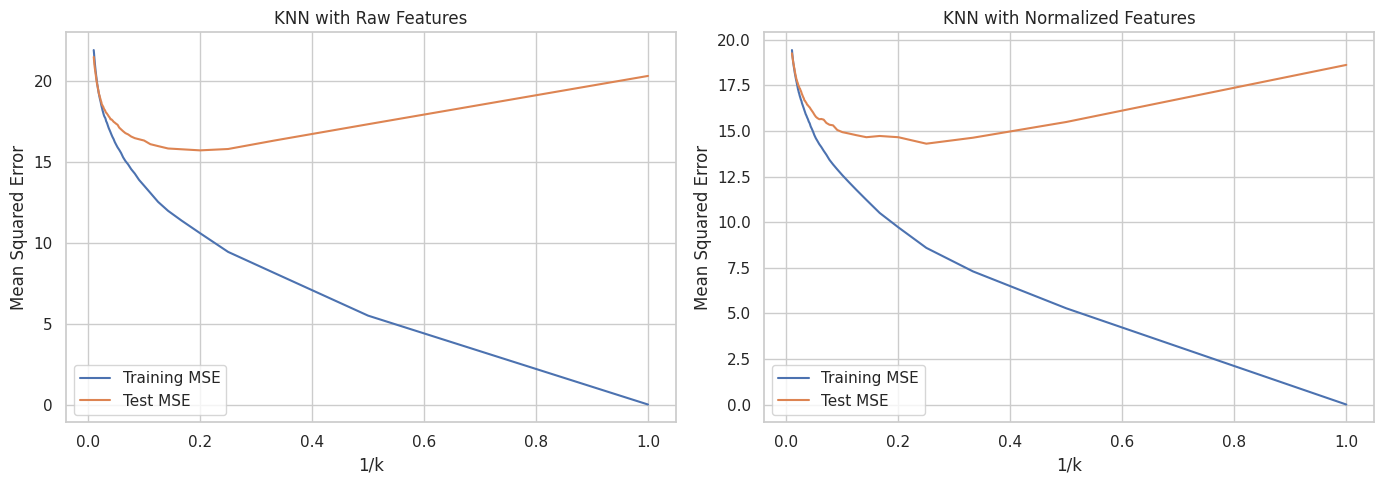

In [24]:
inverse_k = 1 / np.array(list(k_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    inverse_k,
    raw_train_mse,
    label="Training MSE"
)

axes[0].plot(
    inverse_k,
    raw_test_mse,
    label="Test MSE"
)

axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()

axes[1].plot(
    inverse_k,
    normalized_train_mse,
    label="Training MSE"
)

axes[1].plot(
    inverse_k,
    normalized_test_mse,
    label="Test MSE"
)

axes[1].set_title("KNN with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("Mean Squared Error")
axes[1].legend()

plt.tight_layout()
plt.show()

For the raw predictors, the best test performance occurs at \(k=5\), with a test MSE of 15.73. After normalization, the best value is \(k=4\), with a lower test MSE of 14.31.

Normalization improves KNN because the algorithm calculates distances between observations. Without normalization, variables with larger numerical scales, especially ambient pressure, can have too much influence on those distances.

The plots also show the usual tradeoff in choosing \(k\). Very small values of \(k\) fit the training data closely but are more likely to overfit. As \(k\) becomes too large, predictions become overly smooth and both models begin to underfit.

### (j ) Compare KNN and Linear

In [25]:
final_comparison = pd.DataFrame({
    "Model": [
        "Reduced Quadratic and Interaction Regression",
        f"Raw KNN (k={best_raw_k})",
        f"Normalized KNN (k={best_normalized_k})"
    ],
    "Training MSE": [
        improved_train_mse,
        raw_train_mse[best_raw_index],
        normalized_train_mse[best_normalized_index]
    ],
    "Test MSE": [
        improved_test_mse,
        raw_test_mse[best_raw_index],
        normalized_test_mse[best_normalized_index]
    ]
})

final_comparison.round(4)

,Model,Training MSE,Test MSE
0,Reduced Quadratic and Interaction Regression,17.8908,18.6600
1,Raw KNN (k=5),10.6008,15.7268
2,Normalized KNN (k=4),8.5914,14.3057


The reduced quadratic and interaction regression model has a test MSE of 18.66. Both KNN models perform better, with test MSEs of 15.73 for raw KNN and 14.31 for normalized KNN.

The normalized KNN model with \(k=4\) has the lowest test error overall. Its improvement over the regression model suggests that the relationship between the ambient conditions and electrical output includes local patterns that are not fully captured by the quadratic regression model.

Based on test MSE, I would choose normalized KNN as the best predictive model. The regression model is easier to interpret because it provides coefficients for each term, but KNN gives more accurate predictions on this train/test split.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

I would expect a flexible method to perform better. Since there are many observations and only a small number of predictors, the model has enough data to learn a more complicated relationship without being as likely to overfit. A less flexible method could miss useful patterns and have unnecessarily high bias.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

I would expect an inflexible method to perform better. With many predictors but only a small number of observations, a flexible model could easily fit random noise in the training data. A simpler model would have lower variance and would be more likely to generalize to new observations.

### (c) The relationship between the predictors and response is highly non-linear.

I would expect a flexible method to perform better. A flexible model can adapt to curves and other complicated patterns in the relationship between the predictors and response. An inflexible method, such as ordinary linear regression, may be too simple and could underfit the data.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

I would expect an inflexible method to perform better. When the error variance is very high, much of the variation in the response is random noise rather than a pattern that can be learned. A flexible method may try to fit this noise, leading to high variance and poor performance on new data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [26]:
knn_data = pd.DataFrame({
    "Observation": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

test_point = np.array([0, 0, 0])

knn_data["Distance"] = np.sqrt(
    (knn_data["X1"] - test_point[0])**2
    + (knn_data["X2"] - test_point[1])**2
    + (knn_data["X3"] - test_point[2])**2
)

knn_data

,Observation,X1,X2,X3,Y,Distance
0,1,0,3,0,Red,3.000000
1,2,2,0,0,Red,2.000000
2,3,0,1,3,Red,3.162278
3,4,0,1,2,Green,2.236068
4,5,-1,0,1,Green,1.414214
5,6,1,1,1,Red,1.732051


Using the Euclidean distance formula, the distances from the test point are:

- Observation 1: \(3\)
- Observation 2: \(2\)
- Observation 3: \(\sqrt{10} \approx 3.162\)
- Observation 4: \(\sqrt{5} \approx 2.236\)
- Observation 5: \(\sqrt{2} \approx 1.414\)
- Observation 6: \(\sqrt{3} \approx 1.732\)

Observation 5 is the closest point, followed by observations 6 and 2.

### (b) What is our prediction with K = 1? Why?

With \(K=1\), the prediction is **Green**. Observation 5 is the closest training observation to the test point, with a distance of \(\sqrt{2}\), and its class is Green.

### (c) What is our prediction with K = 3? Why?

With \(K=3\), the prediction is **Red**. The three closest observations are observation 5 (Green), observation 6 (Red), and observation 2 (Red). Since two of the three nearest neighbors are Red, the majority vote is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

If the Bayes decision boundary is highly nonlinear, I would expect a relatively small value of \(K\) to work best. A small \(K\) makes KNN more flexible and allows it to follow complicated local patterns. A large \(K\) would average over too many observations, creating a smoother boundary that could miss the nonlinear structure.